<a href="https://colab.research.google.com/github/rudrakshmala/customer-churn-prediction/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("✅ Uploaded:", filename)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
✅ Uploaded: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn Distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


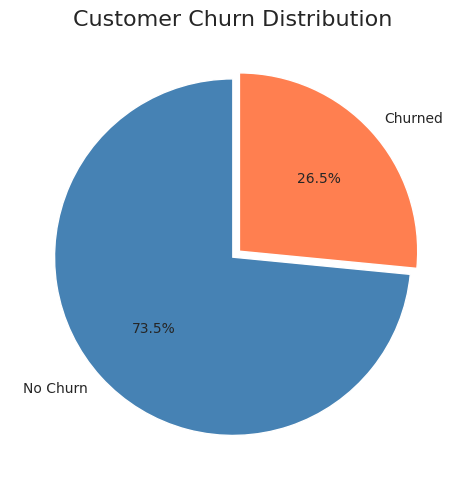

In [4]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 5))
plt.pie(churn_counts, labels=['No Churn', 'Churned'],
        autopct='%1.1f%%', colors=['steelblue', 'coral'],
        startangle=90, explode=(0, 0.05))
plt.title('Customer Churn Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

In [5]:
# Fix TotalCharges column (it has spaces instead of nulls)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("✅ Cleaned Shape:", df.shape)
print("Churn Rate:", round(df['Churn'].mean() * 100, 2), "%")

✅ Cleaned Shape: (7032, 20)
Churn Rate: 26.58 %


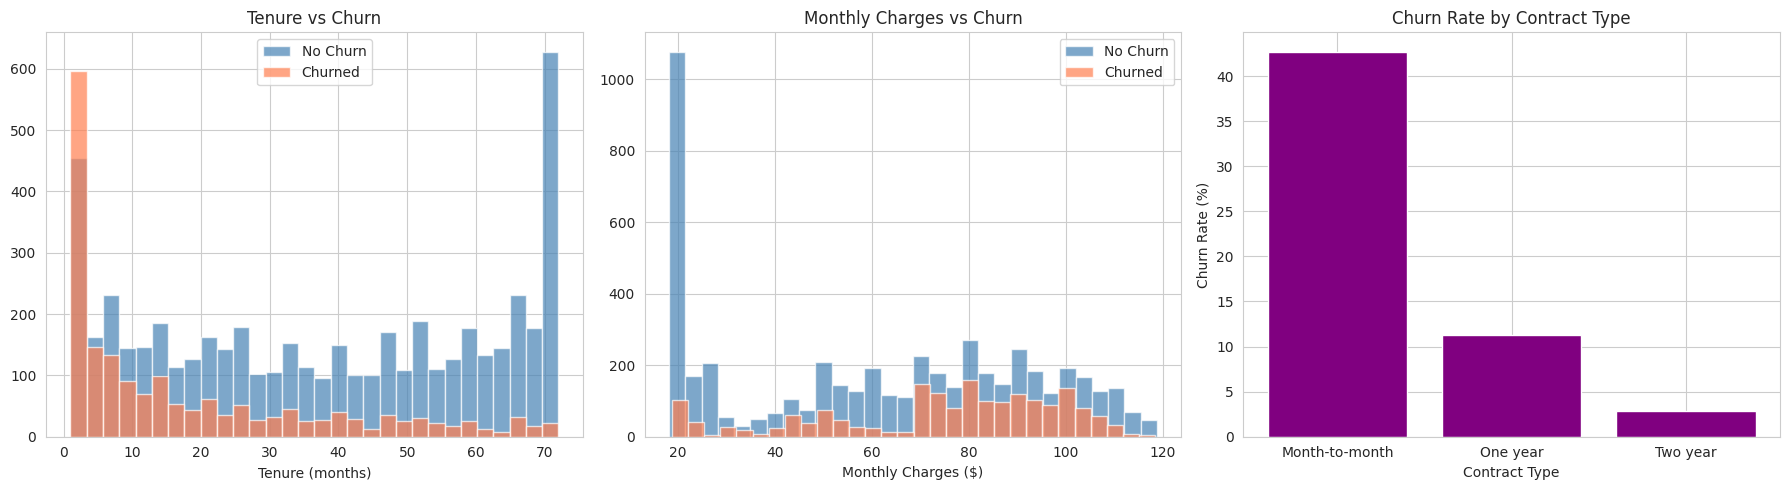

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure vs Churn
axes[0].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.7,
             color='steelblue', label='No Churn')
axes[0].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7,
             color='coral', label='Churned')
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# Monthly Charges vs Churn
axes[1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30, alpha=0.7,
             color='steelblue', label='No Churn')
axes[1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30, alpha=0.7,
             color='coral', label='Churned')
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

# Contract Type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[2].bar(contract_churn.index, contract_churn.values, color='purple')
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('feature_exploration.png', dpi=150)
plt.show()

In [7]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Encoding columns:", categorical_cols)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Encoding done!")
df.head()

Encoding columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
✅ Encoding done!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


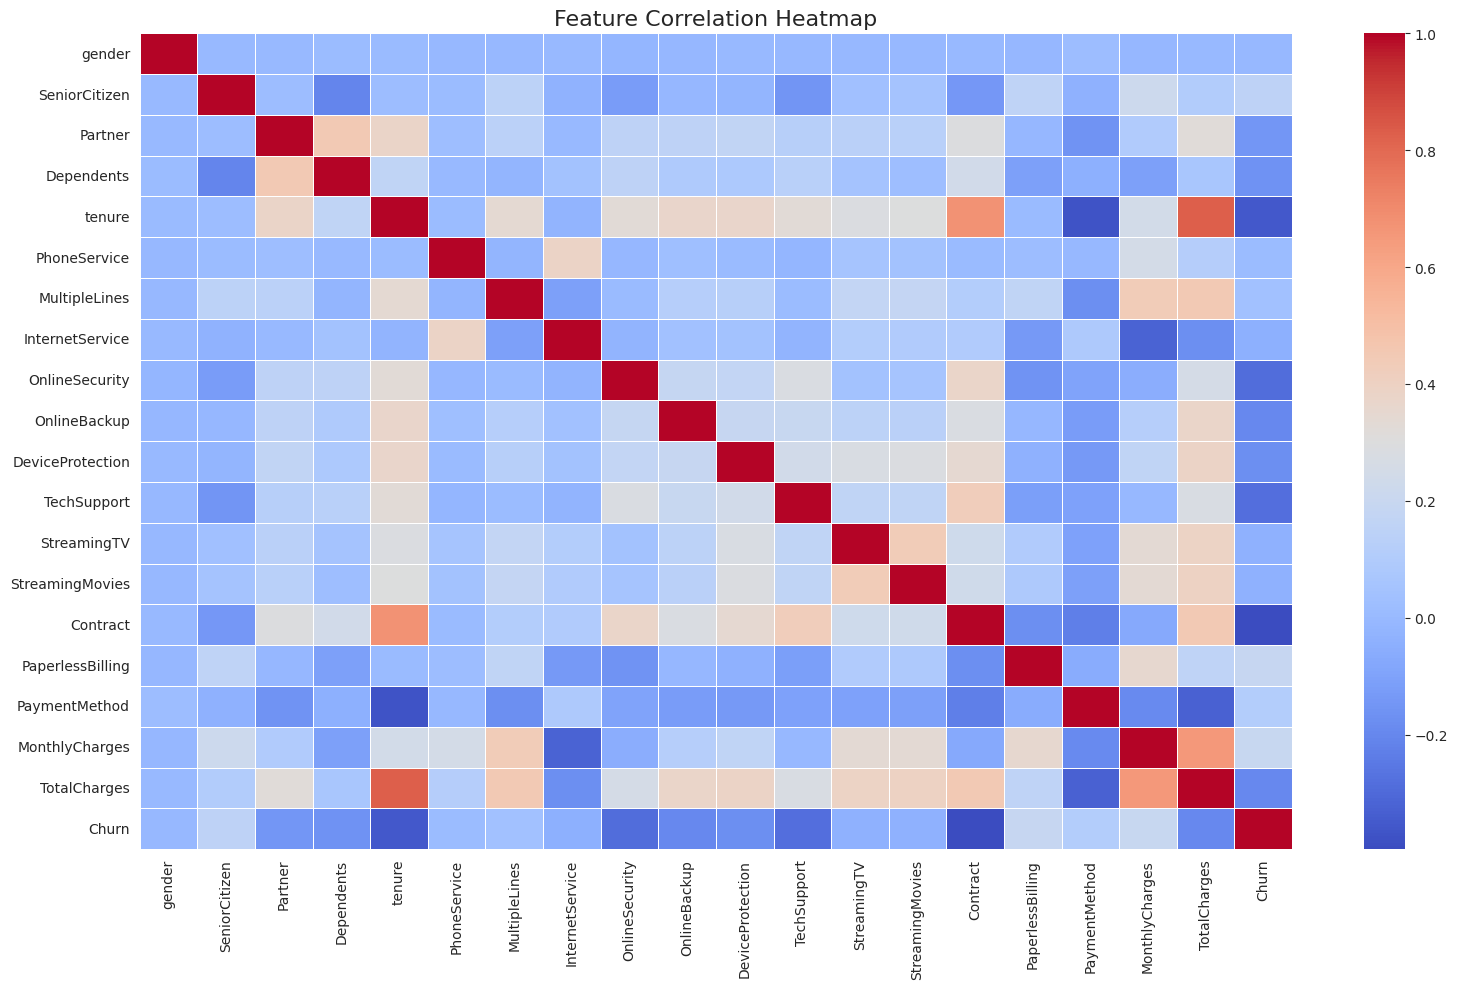

In [8]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Train size:", X_train.shape)
print("✅ Test size:", X_test.shape)

✅ Train size: (5625, 19)
✅ Test size: (1407, 19)


In [10]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test, lr_pred,
      target_names=['No Churn', 'Churned']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_pred), 4))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
     Churned       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407

ROC-AUC Score: 0.7206


In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=" * 45)
print("RANDOM FOREST RESULTS")
print("=" * 45)
print(classification_report(y_test, rf_pred,
      target_names=['No Churn', 'Churned']))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_pred), 4))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
     Churned       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407

ROC-AUC Score: 0.6851


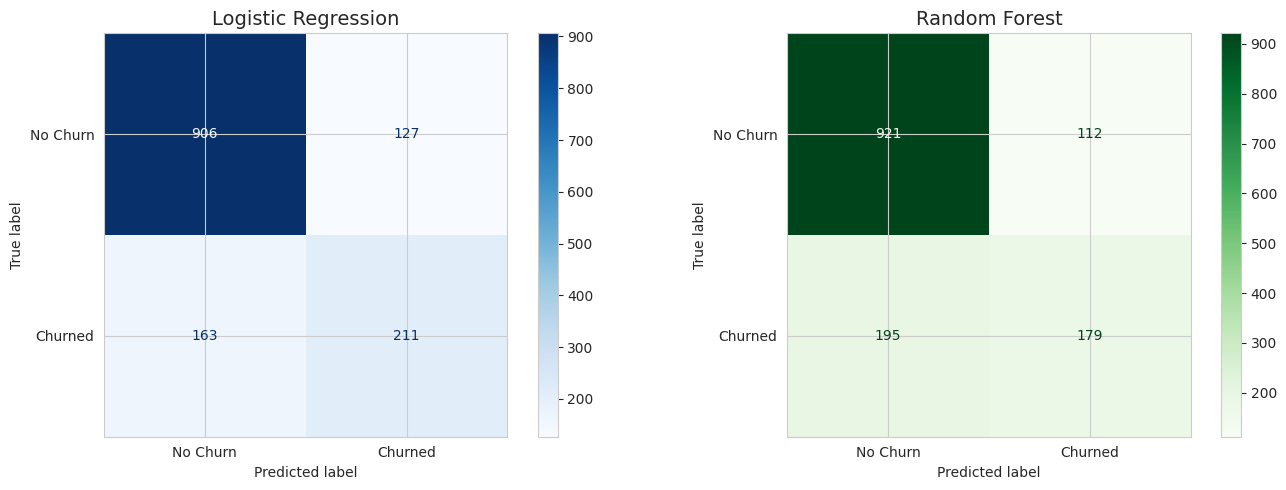

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['No Churn', 'Churned'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression', fontsize=14)

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['No Churn', 'Churned'],
    cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest', fontsize=14)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

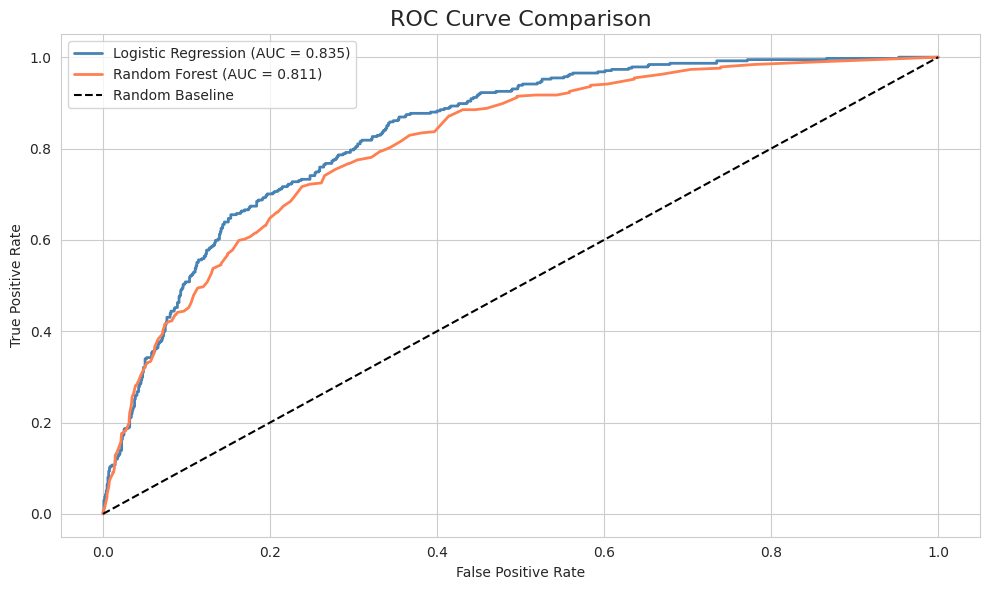

In [13]:
lr_proba = lr.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(10, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})',
         color='steelblue', linewidth=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_proba):.3f})',
         color='coral', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

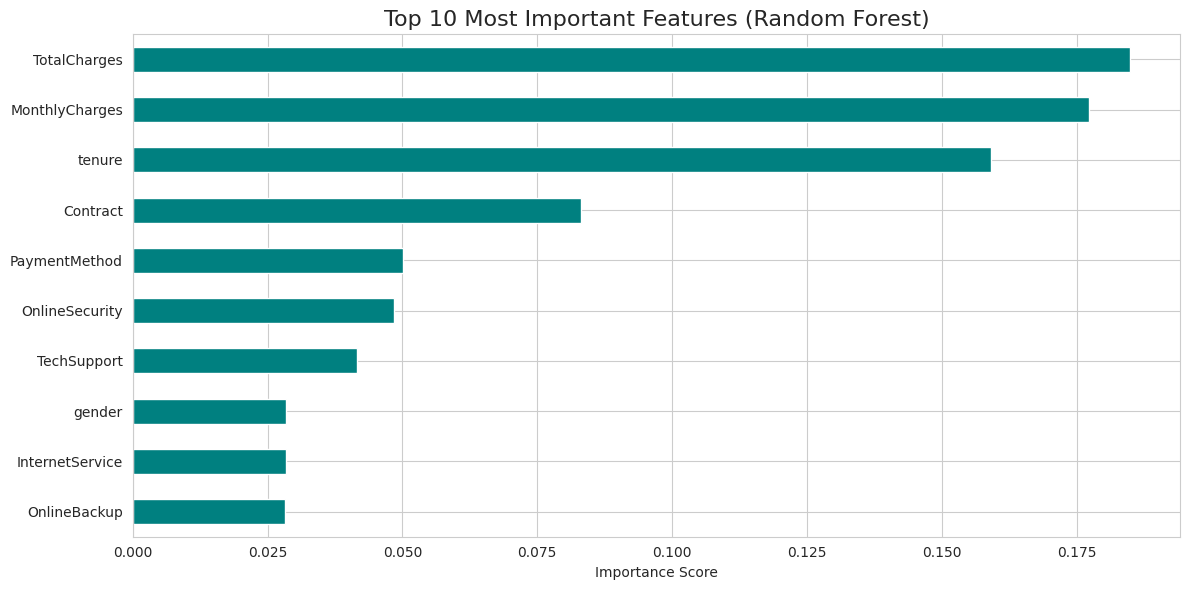

In [14]:
feature_names = df.drop('Churn', axis=1).columns
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
importances.plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Random Forest)', fontsize=16)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [15]:
print("=" * 50)
print("🔄 CHURN PREDICTION — SUMMARY")
print("=" * 50)
print(f"\n👥 Total Customers Analyzed : {len(df):,}")
print(f"📉 Overall Churn Rate       : {round(df['Churn'].mean()*100, 2)}%")
print(f"\n📊 Logistic Regression AUC  : {round(roc_auc_score(y_test, lr_proba), 4)}")
print(f"🌲 Random Forest AUC        : {round(roc_auc_score(y_test, rf_proba), 4)}")
print(f"\n🏆 Best Model               : {'Random Forest' if roc_auc_score(y_test, rf_proba) > roc_auc_score(y_test, lr_proba) else 'Logistic Regression'}")
print(f"🔑 Top Churn Factor         : {importances.index[0]}")
print("=" * 50)

🔄 CHURN PREDICTION — SUMMARY

👥 Total Customers Analyzed : 7,032
📉 Overall Churn Rate       : 26.58%

📊 Logistic Regression AUC  : 0.8345
🌲 Random Forest AUC        : 0.8107

🏆 Best Model               : Logistic Regression
🔑 Top Churn Factor         : TotalCharges


In [16]:
import os
charts = ['churn_distribution.png', 'feature_exploration.png',
          'correlation_heatmap.png', 'confusion_matrices.png',
          'roc_curve.png', 'feature_importance.png']

for chart in charts:
    if os.path.exists(chart):
        files.download(chart)

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
